In [1]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import OrdinalEncoder

In [2]:
# Functions for cleaning data

def remove_percentage(x):
    if pd.notnull(x):
        return pd.to_numeric(x[0:len(x) - 1])
    
def region_cleaning(x):
    if pd.isnull(x) or x == 'Various':
        return 'Unspecified'
    elif x.startswith('In') or x.startswith('in'):
        if x == 'In Europe':
            return 'Unspecified Europe'
        return x[3:len(x)]
    elif x == 'Minesota':
        return 'Minnesota'
    elif x == 'GER':
        return 'Germany'
    elif x == 'DEN':
        return 'Denmark'
    elif x == 'FIN':
        return 'Finland'
    elif x == 'NOR':
        return 'Norway'
    elif x == 'SWE':
        return 'Sweden'
    elif x == 'Nordic':
        return 'Unspecified Nordic'
    elif x == 'Europe':
        return 'Unspecified Europe'
    else:
        return x
    
def region_condensing(x):
    if x in ['California', 'Colorado', 'Minnesota']:
        return 'US'
    elif x in ['Ireland', 'Finland', 'France', 'Germany', 'Denmark', 'Sweden', 'Austria', 
               'Belgium', 'Czech Republic', 'Spain', 'Greece', 'Italy', 'Portugal', 'The Netherlands']:
        return 'EU'
    else:
        return x
    
def resource_cleaning(x):
    if x.find(',') == -1:
        return 'Unspecified resource'
    elif x[x.find(',') - 1] == '0':
        return 'Mixed Solar + Wind'
    elif x[x.find(',') - 1] == 'V':
        return 'Solar'
    else:
        return x[0:x.find(',')]
    
def resource_condensing(x):
    if x[len(x) - 4:len(x)] == 'wind':
        return 'Wind'
    else:
        return x

In [3]:
# Read in the data, clean the data, and add some new variables

cost_dfs = ['operating_reserve_costs', 'capacity_costs', 'profile_costs', 'aggregated_costs']
costs = ['Operating reserve costs', 'Capacity costs', 'Profile costs', 'Aggregated costs']

for i in range(0, len(cost_dfs)):
    cost_dfs[i] = pd.read_csv(f'{cost_dfs[i]}.csv')
    cost_dfs[i] = cost_dfs[i].dropna()
    cost_dfs[i]['Penetration level'] = cost_dfs[i]['Penetration level'].apply(remove_percentage)
    cost_dfs[i]['Region'] = cost_dfs[i]['Region'].apply(region_cleaning)
    if i < 3:
        cost_dfs[i]['Condensed Region'] = cost_dfs[i]['Region'].apply(region_condensing)
        if i == 2:
            cost_dfs[i] = cost_dfs[i].rename(columns = {'Notes':'Resource'})
            cost_dfs[i]['Resource'] = cost_dfs[i]['Resource'].apply(resource_cleaning)
    else:
        cost_dfs[i] = cost_dfs[i].rename(columns = {'Notes':'Resource'})
        cost_dfs[i]['Condensed Resource'] = cost_dfs[i]['Resource'].apply(resource_cleaning)
        cost_dfs[i]['Extra Condensed Resource'] = cost_dfs[i]['Condensed Resource'].apply(resource_condensing)

In [ ]:
# Get a preview of each df

for i in range(0, 4):
    print(costs[i])
    display(HTML(cost_dfs[i].head().to_html()))
    print('')

Operating reserve costs


,Penetration level,2017 €/MWh,Region,Condensed Region
2,4.0,0.03,UK,UK
3,8.0,0.14,UK,UK
4,12.0,0.26,UK,UK
5,16.0,0.38,UK,UK
6,20.0,0.52,UK,UK



Capacity costs


,Penetration level,2017 €/MWh,Region,Condensed Region
0,20.0,0.93,UK,UK
1,2.0,6.15,Austria,EU
2,4.0,8.51,Austria,EU
3,6.0,10.87,Austria,EU
4,8.0,11.99,Austria,EU



Profile costs


,Year,Penetration level,2017 €/MWh,Region,Resource,Condensed Region
0,2001,2.0,-1.34,Germany,Wind,EU
1,2004,3.0,0.00,Germany,Wind,EU
2,2005,3.5,0.00,Germany,Wind,EU
3,2006,4.7,2.41,Germany,Wind,EU
4,2007,4.9,5.88,Germany,Wind,EU



Aggregated costs


,Year,Penetration level,2017 €/MWh,Region,Resource,Condensed Resource,Extra Condensed Resource
0,2015,36.4,8.99,UK,"Offshore wind, CCC 2015",Offshore wind,Wind
1,2015,36.3,19.11,UK,"Offshore wind, CCC 2015",Offshore wind,Wind
2,2015,36.1,32.32,UK,"Offshore wind, CCC 2015",Offshore wind,Wind
3,2015,47.0,51.86,UK,"Offshore wind, CCC 2015",Offshore wind,Wind
4,2015,48.0,49.75,UK,"Offshore wind, CCC 2015",Offshore wind,Wind


In [5]:
# View unique regions for each df

"""
For aggregated costs, it is unlikely any meaningful insights would be found from differentiating between UK data and unspecified data, since it is unknown how much of
the unspecified data may even be from places outside of the UK.
"""

for i in range(0, 4):
    print(costs[i])
    print(cost_dfs[i]['Region'].unique())
    print('')

Operating reserve costs
['UK' 'California' 'EU' 'US' 'Ireland' 'Finland' 'France' 'Germany'
 'Korea' 'Colorado' 'Minnesota' 'Denmark' 'Norway' 'Sweden']

Capacity costs
['UK' 'Austria' 'Belgium' 'Czech Republic' 'Spain' 'Germany'
 'Unspecified Europe' 'France' 'Greece' 'Italy' 'Portugal'
 'The Netherlands' 'Finland' 'Korea' 'US' 'EU' 'Sweden']

Profile costs
['Germany' 'Unspecified' 'Unspecified Nordic']

Aggregated costs
['UK' 'Unspecified Europe']



In [6]:
# View unique condensed regions for each df

"""
For profile costs, it is unlikely any meaningful insights would be found from differentiating between EU data and unspecified data, since it is unknown how much of the
unspecified data may even be from places outside of the EU.
"""

for i in range(0, 3):
    print(costs[i])
    print(cost_dfs[i]['Condensed Region'].unique())
    print('')

Operating reserve costs
['UK' 'US' 'EU' 'Korea' 'Norway']

Capacity costs
['UK' 'EU' 'Unspecified Europe' 'Korea' 'US']

Profile costs
['EU' 'Unspecified' 'Unspecified Nordic']



In [ ]:
# View unique years for each df

"""
Latest year in any df is 2015, likely too outdated to be a useful predictor
"""

for i in range(2, 4):
    print(costs[i])
    print(cost_dfs[i]['Year'].unique())
    print('')

Profile costs
[2001 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2015 2014]

Aggregated costs
[2015 2009]



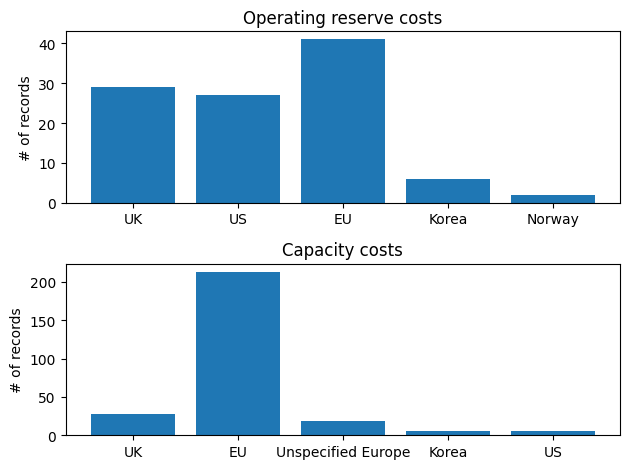

In [9]:
# Construct bar charts for condensed region

"""
For each cost type, regions are largely imbalanced in terms of how much data each region has. For operating reserve costs, data is fairly evenly spread between 
the UK, US, and EU, but not between other regions. For capacity costs, the EU has way more data than any other region.
"""

for i in range(211, 213):
    x = []
    y = []
    for j in cost_dfs[i - 211]['Condensed Region'].unique():
        x.append(j)
        y.append(cost_dfs[i - 211]['Condensed Region'].value_counts()[j])
    plt.subplot(i)
    plt.bar(x, y)
    plt.ylabel('# of records')
    plt.title(costs[i - 211])
plt.tight_layout()
plt.show()

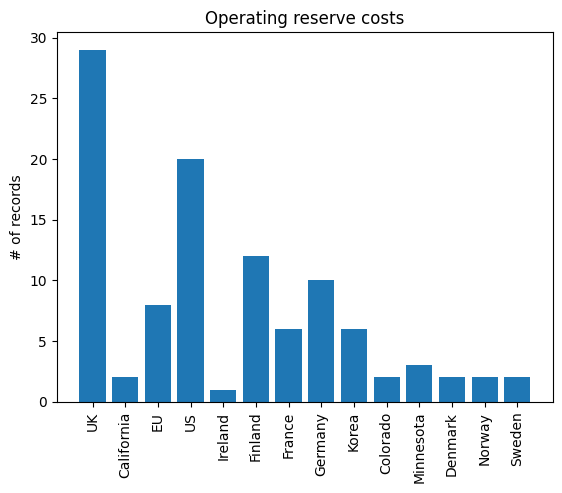

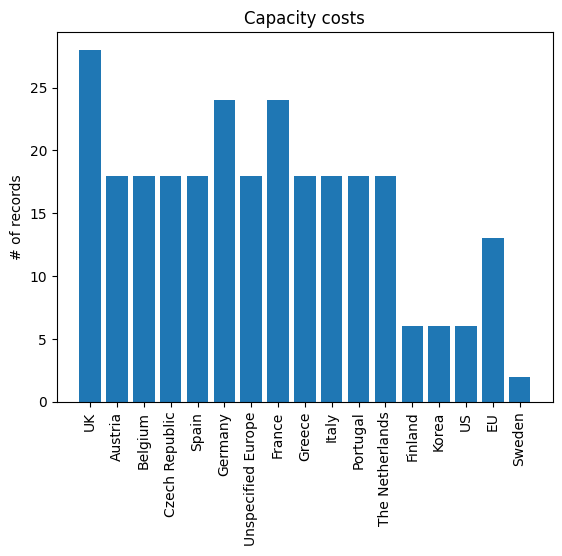

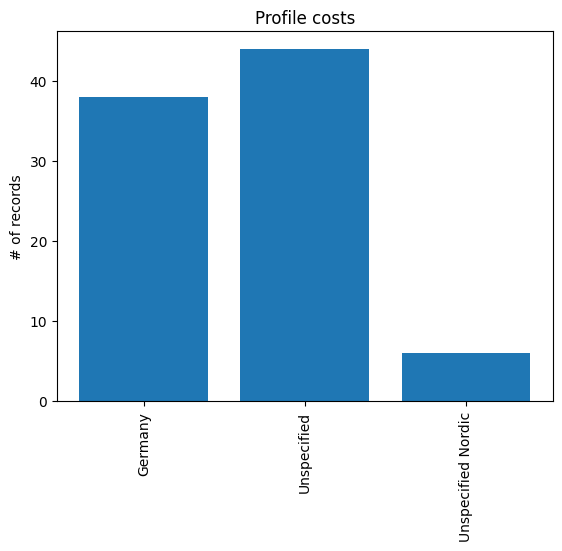

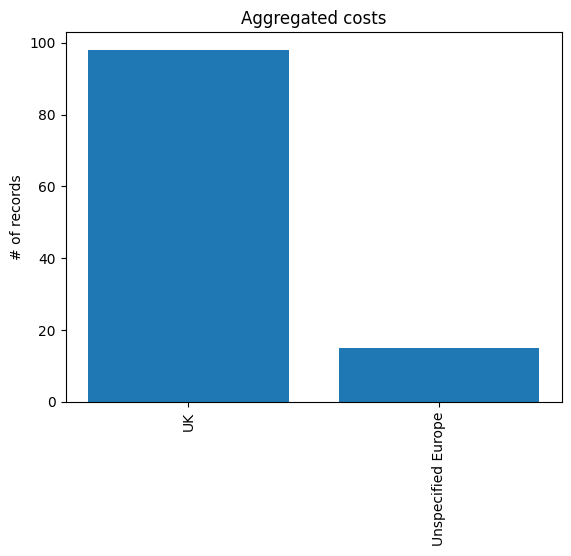

In [10]:
# Construct bar charts for region

"""
For operating reserve costs, data appears to be fairly unevenly spread between different regions. For capacity costs, data appears to be mostly evenly spread between
different regions. For profile costs, data is fairly evenly spread between 'Germany' and 'Unspecified', but it is unlikely any meaningful insights would be found from
differentiating between Germany data and unspecified data. For aggregated costs, almost all of the data comes from the UK.
"""

for i in range(0, 4):
    x = []
    y = []
    for j in cost_dfs[i]['Region'].unique():
        x.append(j)
        y.append(cost_dfs[i]['Region'].value_counts()[j])
    plt.bar(x, y)
    plt.ylabel('# of records')
    plt.title(costs[i])
    plt.xticks(rotation = 90)
    plt.show()

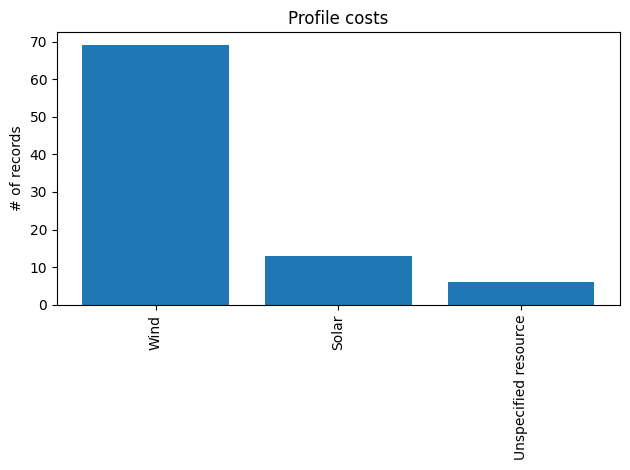

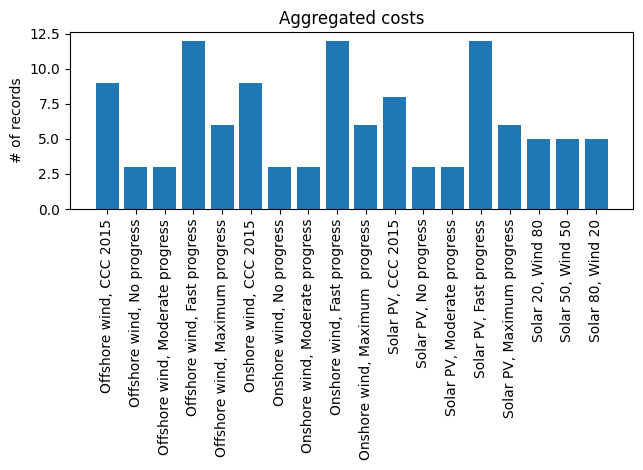

In [11]:
# Construct bar charts for resource

"""
For profile costs, wind has way more data than solar. For aggregated costs, resources with higher rates of progress have more data than resources with lower rates of
progress.
"""

for i in range(2, 4):
    x = []
    y = []
    for j in cost_dfs[i]['Resource'].unique():
        x.append(j)
        y.append(cost_dfs[i]['Resource'].value_counts()[j])
    plt.bar(x, y)
    plt.ylabel('# of records')
    plt.title(costs[i])
    plt.xticks(rotation = 90)
    plt.tight_layout()
    plt.show()

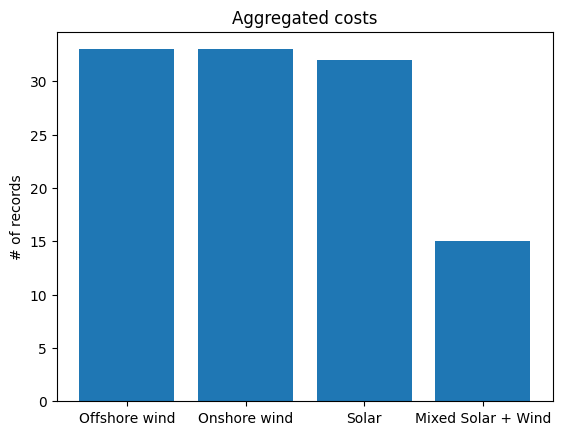

In [12]:
# Construct bar chart for condensed resource

"""
For aggregated costs, although mixed solar and wind has less data than other resources, data is very evenly distributed between offshore wind, onshore wind, and solar.
"""

x = []
y = []
for i in cost_dfs[3]['Condensed Resource'].unique():
    x.append(i)
    y.append(cost_dfs[3]['Condensed Resource'].value_counts()[i])
plt.bar(x, y)
plt.ylabel('# of records')
plt.title(costs[3])
plt.show()

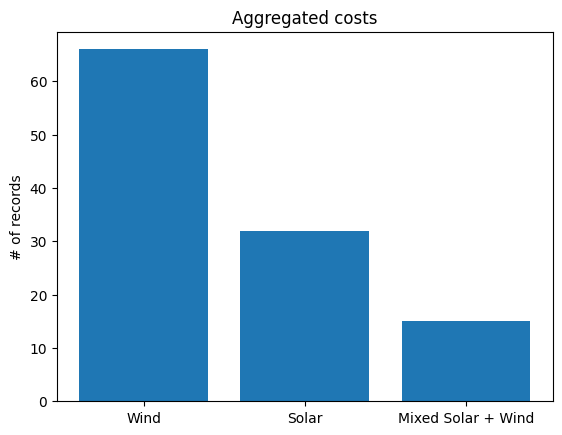

In [13]:
# Construct bar chart for extra condensed resource

"""
For aggregated costs, wind has much more data than solar, and solar has much more data than mixed solar and wind.
"""

x = []
y = []
for i in cost_dfs[3]['Extra Condensed Resource'].unique():
    x.append(i)
    y.append(cost_dfs[3]['Extra Condensed Resource'].value_counts()[i])
plt.bar(x, y)
plt.ylabel('# of records')
plt.title(costs[3])
plt.show()

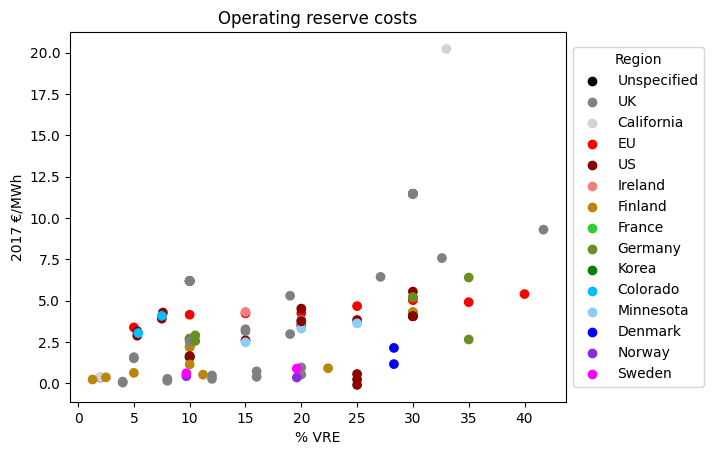

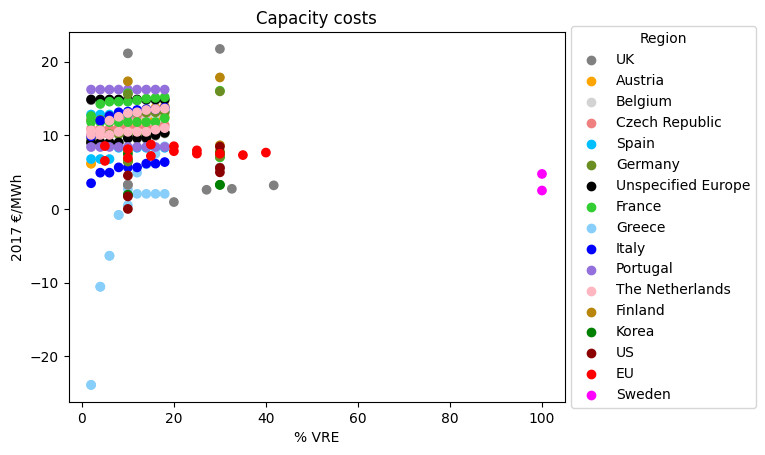

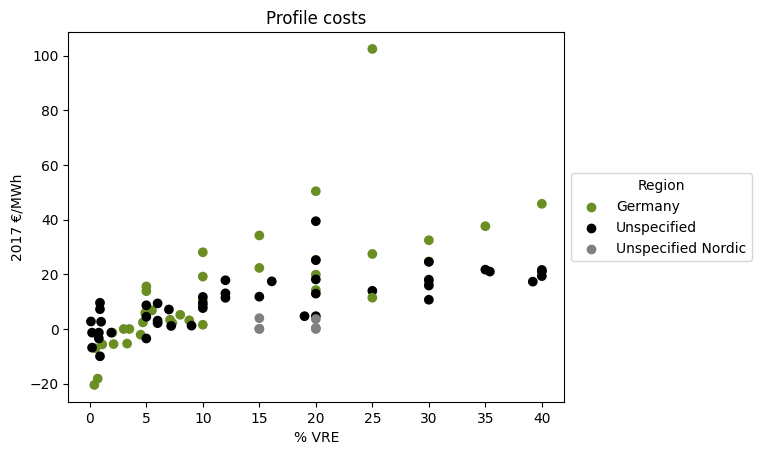

In [ ]:
# Construct scatterplots comparing the %VRE and cost for each type of cost while also coloring by region

"""
For operating and profile costs, there do not appear to be any notable differences between regions in the %VRE and cost relationship. For capacity costs, though, there 
do appear to be notable differences between regions in the %VRE and cost relationship.
"""

cm_or_costs = {'Unspecified': 'black', 'UK': 'gray', 'California': 'lightgray', 'EU': 'red', 'US': 'darkred', 'Ireland': 'lightcoral', 'Finland': 'darkgoldenrod', 
                'France': 'limegreen', 'Germany': 'olivedrab', 'Korea': 'green', 'Colorado': 'deepskyblue', 'Minnesota': 'lightskyblue', 'Denmark': 'blue', 
                'Norway': 'blueviolet', 'Sweden': 'magenta'}
cm_capacity_costs = {'UK': 'gray', 'Austria': 'orange', 'Belgium': 'lightgray', 'Czech Republic': 'lightcoral', 'Spain': 'deepskyblue', 'Germany': 'olivedrab', 
                        'Unspecified Europe': 'black', 'France': 'limegreen', 'Greece': 'lightskyblue', 'Italy': 'blue', 'Portugal': 'mediumpurple', 
                        'The Netherlands': 'lightpink', 'Finland': 'darkgoldenrod', 'Korea': 'green', 'US': 'darkred', 'EU': 'red', 'Sweden': 'magenta'}
cm_profile_costs = {'Germany': 'olivedrab', 'Unspecified': 'black', 'Unspecified Nordic': 'gray'}
cms = [cm_or_costs, cm_capacity_costs, cm_profile_costs]
for i in range(0, 3):
    colors = [cms[i][region] for region in cost_dfs[i]['Region']]
    plt.scatter(cost_dfs[i]['Penetration level'], cost_dfs[i]['2017 €/MWh'], c = colors)
    for region, color in cms[i].items():
        plt.scatter([], [], c = color, label = region) # Create dummy points for legend
    plt.legend(title = 'Region', loc = 'center left', bbox_to_anchor = (1, 0.5))
    plt.xlabel('% VRE')
    plt.ylabel('2017 €/MWh')
    plt.title(costs[i])
    plt.show()

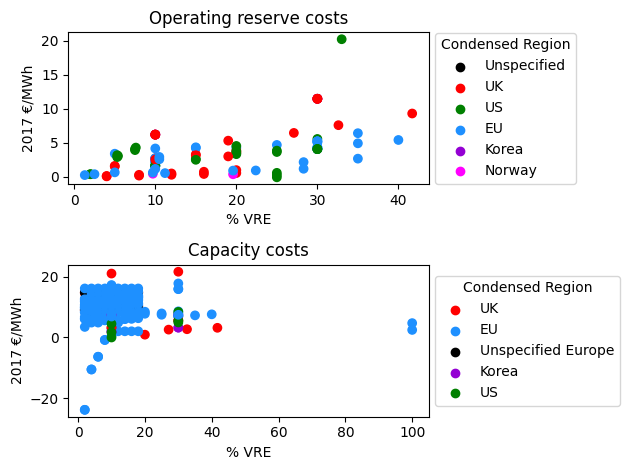

In [ ]:
# Construct scatterplots comparing the %VRE and cost for each type of cost while also coloring by condensed region

"""
For each type of cost, there do not appear to be any notable differences between regions in the %VRE and cost relationship.
"""

cm_or_costs = {'Unspecified': 'black', 'UK': 'red', 'US': 'green', 'EU': 'dodgerblue', 'Korea': 'darkviolet', 'Norway': 'magenta'}
cm_capacity_costs = {'UK': 'red', 'EU': 'dodgerblue', 'Unspecified Europe': 'black', 'Korea': 'darkviolet', 'US': 'green'}
cms = [cm_or_costs, cm_capacity_costs]
for i in range(211, 213):
    colors = [cms[i - 211][condensed_region] for condensed_region in cost_dfs[i - 211]['Condensed Region']]
    plt.subplot(i)
    plt.scatter(cost_dfs[i - 211]['Penetration level'], cost_dfs[i - 211]['2017 €/MWh'], c = colors)
    for condensed_region, color in cms[i - 211].items():
        plt.scatter([], [], c = color, label = condensed_region) # Create dummy points for legend
    plt.legend(title = 'Condensed Region', loc = 'center left', bbox_to_anchor = (1, 0.5))
    plt.xlabel('% VRE')
    plt.ylabel('2017 €/MWh')
    plt.title(costs[i - 211])
    plt.tight_layout()
plt.show()

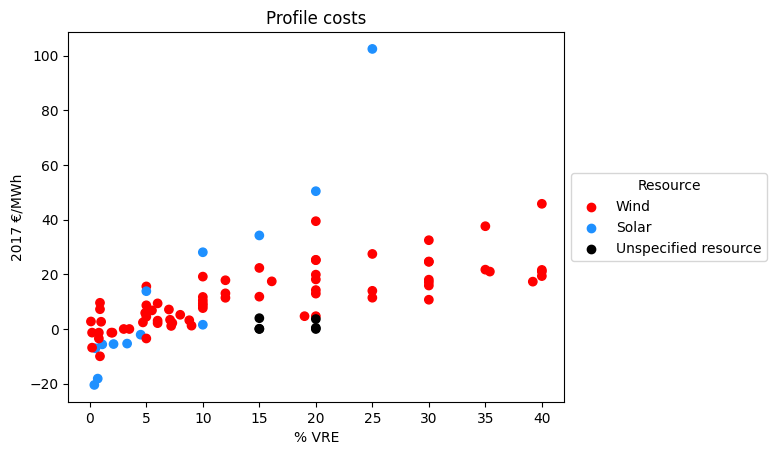

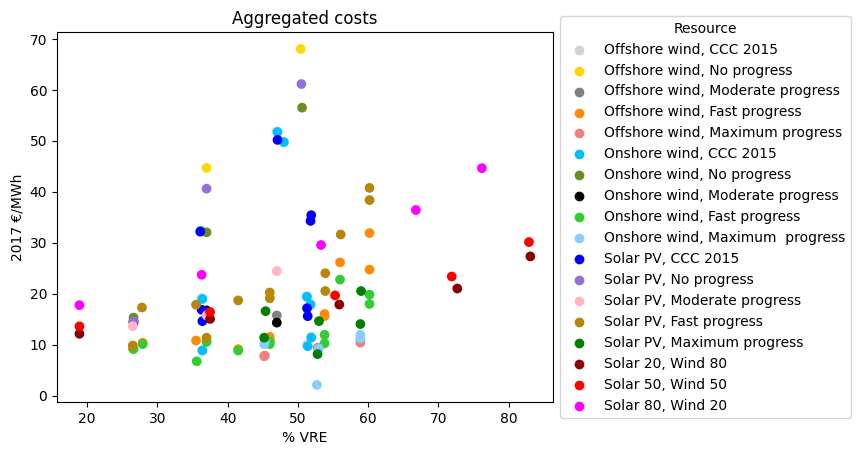

In [ ]:
# Construct scatterplots comparing the %VRE and cost for each type of cost while also coloring by resource

"""
For profile costs, it appears there are notable differences between resources in the %VRE and cost relationship, but for aggregated costs, it does not appear there are
any notable differences between resources in the %VRE and cost relationship.
"""

cm_profile_costs = {'Wind': 'red', 'Solar': 'dodgerblue', 'Unspecified resource': 'black'}
cm_aggregated_costs = {'Offshore wind, CCC 2015': 'lightgray', 'Offshore wind, No progress': 'gold', 'Offshore wind, Moderate progress': 'gray', 
                        'Offshore wind, Fast progress': 'darkorange', 'Offshore wind, Maximum progress': 'lightcoral', 'Onshore wind, CCC 2015': 'deepskyblue', 
                        'Onshore wind, No progress': 'olivedrab', 'Onshore wind, Moderate progress': 'black', 'Onshore wind, Fast progress': 'limegreen', 
                        'Onshore wind, Maximum  progress': 'lightskyblue', 'Solar PV, CCC 2015': 'blue', 'Solar PV, No progress': 'mediumpurple', 
                        'Solar PV, Moderate progress': 'lightpink', 'Solar PV, Fast progress': 'darkgoldenrod', 'Solar PV, Maximum progress': 'green', 
                        'Solar 20, Wind 80': 'darkred', 'Solar 50, Wind 50': 'red', 'Solar 80, Wind 20': 'magenta'}
cms = [cm_profile_costs, cm_aggregated_costs]
for i in range(0, 2):
    colors = [cms[i][resource] for resource in cost_dfs[i + 2]['Resource']]
    plt.scatter(cost_dfs[i + 2]['Penetration level'], cost_dfs[i + 2]['2017 €/MWh'], c = colors)
    for resource, color in cms[i].items():
        plt.scatter([], [], c = color, label = resource) # Create dummy points for legend
    plt.legend(title = 'Resource', loc = 'center left', bbox_to_anchor = (1, 0.5))
    plt.xlabel('% VRE')
    plt.ylabel('2017 €/MWh')
    plt.title(costs[i + 2])
    plt.show()

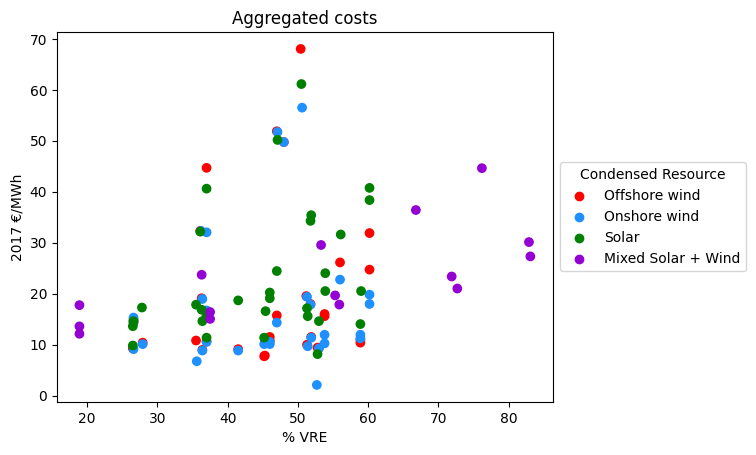

In [38]:
# Construct a scatterplot comparing the %VRE and cost for aggregated costs while also coloring by condensed resource

"""
It does not appear there are any notable differences between resources in the %VRE and cost relationship.
"""

color_map = {'Offshore wind': 'red', 'Onshore wind': 'dodgerblue', 'Solar': 'green', 'Mixed Solar + Wind': 'darkviolet'}
colors = [color_map[condensed_resource] for condensed_resource in cost_dfs[3]['Condensed Resource']]
plt.scatter(cost_dfs[3]['Penetration level'], cost_dfs[3]['2017 €/MWh'], c = colors)
for condensed_resource, color in color_map.items():
    plt.scatter([], [], c = color, label = condensed_resource) # Create dummy points for legend
plt.legend(title = 'Condensed Resource', loc = 'center left', bbox_to_anchor = (1, 0.5))
plt.xlabel('% VRE')
plt.ylabel('2017 €/MWh')
plt.title(costs[3])
plt.show()

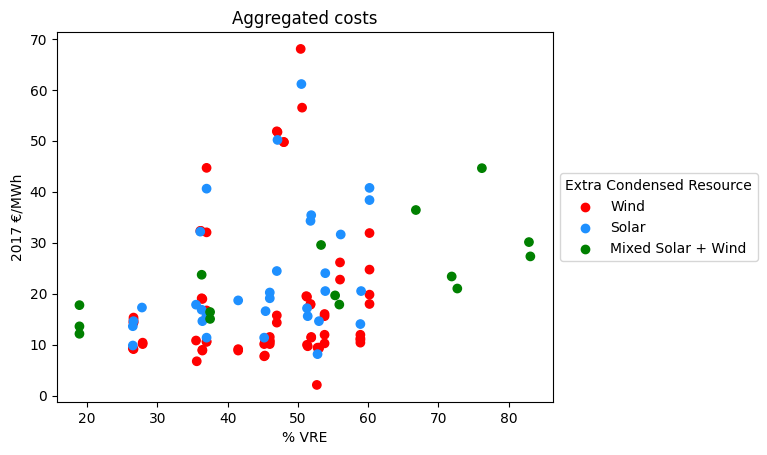

In [40]:
# Construct a scatterplot comparing the %VRE and cost for aggregated costs while also coloring by extra condensed resource

"""
It does not appear there are any notable differences between resources in the %VRE and cost relationship.
"""

color_map = {'Wind': 'red', 'Solar': 'dodgerblue', 'Mixed Solar + Wind': 'green'}
colors = [color_map[extra_condensed_resource] for extra_condensed_resource in cost_dfs[3]['Extra Condensed Resource']]
plt.scatter(cost_dfs[3]['Penetration level'], cost_dfs[3]['2017 €/MWh'], c = colors)
for extra_condensed_resource, color in color_map.items():
    plt.scatter([], [], c = color, label = extra_condensed_resource) # Create dummy points for legend
plt.legend(title = 'Extra Condensed Resource', loc = 'center left', bbox_to_anchor = (1, 0.5))
plt.xlabel('% VRE')
plt.ylabel('2017 €/MWh')
plt.title(costs[3])
plt.show()

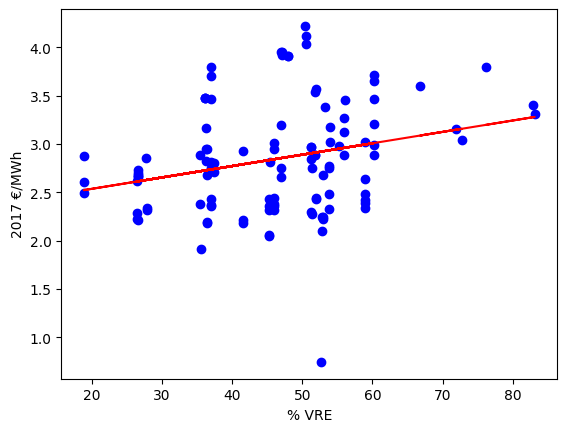

Root Mean Squared Error: 0.8917174990088595


In [ ]:
# Potential predictors that could work well with the aggregated costs table, based on the above EDA: %VRE
# Looking back at the EDA plots, the relationship looks exponential, so will use an exponential model

"""
This model is better than an operating reserve + capacity + profile cost model because as seen below, even just one component of the operating reserve + capacity + 
profile cost model (the capacity cost component) has a higher RMSE than this model, and since the operating reserve + capacity + profile cost model is additive, their
RMSEs will be additive as well. 

Using exponential models to predict renewable energy integration costs is also supported by a group of researchers from Oxford University, as detailed in the following podcast: 
https://xenetwork.org/ets/episodes/episode-159-the-cost-of-decarbonization/.
"""

x = cost_dfs[3][['Penetration level']]
y = np.log(cost_dfs[3]['2017 €/MWh'])
agg_model = LinearRegression().fit(x, y)
score = np.exp(cross_val_score(agg_model, x, y, cv = LeaveOneOut(), scoring = "neg_mean_squared_error"))
rmse = np.sqrt(np.abs(score).mean())
plt.scatter(x, y, color = 'blue')
plt.xlabel('% VRE')
plt.ylabel('2017 €/MWh')
plt.plot(x, agg_model.predict(x), color = 'r')
plt.show()

print("Root Mean Squared Error:", rmse) # 0.89 (better model than operating reserve + capacity + profile cost model)

Root Mean Squared Error: 5.384931282257504


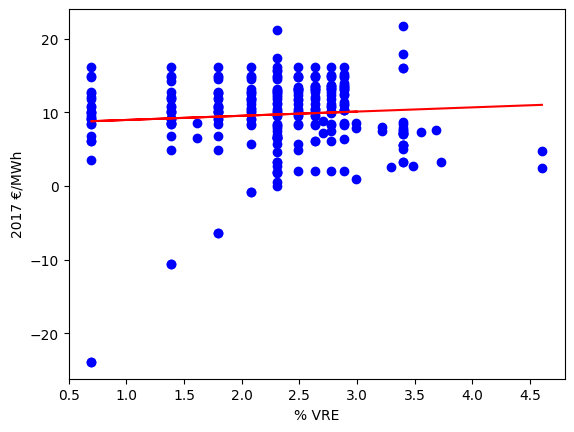

In [ ]:
# Potential predictors that could work well with the capacity costs table: %VRE, region
# For simplicity, though, will first try only using %VRE as a predictor

# Looking back at the EDA plots, the relationship looks logarithmic, so will use a logarithmic model

cost_dfs[1]['Log Penetration level'] = np.log(cost_dfs[1]['Penetration level'])
x = cost_dfs[1][['Log Penetration level']]
y = cost_dfs[1][['2017 €/MWh']]
cap_model_1 = LinearRegression().fit(x, y)
score = cross_val_score(cap_model_1, x, y, cv = LeaveOneOut(), scoring = "neg_mean_squared_error")
rmse = np.sqrt(np.abs(score).mean())
plt.scatter(x, y, color = 'blue')
plt.xlabel('% VRE')
plt.ylabel('2017 €/MWh')
plt.plot(x, cap_model_1.predict(x), color = 'r')

print("Root Mean Squared Error:", rmse) # 5.38

In [ ]:
# Now try adding Region as a predictor to the above model

enc = OrdinalEncoder()
cost_dfs[1][['Region']] = enc.fit_transform(cost_dfs[1][['Region']])
x = cost_dfs[1][['Log Penetration level', 'Region']]
y = cost_dfs[1][['2017 €/MWh']]
cap_model_2 = LinearRegression().fit(x, y)
score = cross_val_score(cap_model_2, x, y, cv = LeaveOneOut(), scoring = "neg_mean_squared_error")
rmse = np.sqrt(np.abs(score).mean())

print("Root Mean Squared Error:", rmse) # 5.39

Root Mean Squared Error: 5.394514480215669


In [ ]:
# Use the best model to make predictions

type_is_numeric = False
invalid_input = True
while invalid_input == True:
    penetration_level = input("Enter a renewable energy penetration level for a grid, as expressed by a percentage (e.g. XX.XX%, but do not include the percentage sign): ")
    try:
        penetration_level = float(penetration_level)
        type_is_numeric = True
    except:
        print("Penetration level must not include non-numeric characters")
    if type_is_numeric == True:
        if penetration_level < 0:
            print("Penetration level cannot be negative")
        elif penetration_level > 100:
            print("Penetration level cannot be greater than 100")
        else:
            invalid_input = False
pred_cost = np.exp(penetration_level*agg_model.coef_[0] + agg_model.intercept_)*1.13*1.31 # In 2017, €1 = $1.13 USD, and $1 USD in 2017 = $1.31 USD in 2025
print(f"A renewable energy penetration level of {penetration_level}% has an estimated cost of ${round(pred_cost, 2)}/MWh")